# 02. 무작위 실험 & 통계분석

In [2]:
import warnings
warnings.filterwarnings('ignore')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
style.use("fivethirtyeight")

<br>

<hr>

<br>

## 02.01. 무작위 배정을 통한 독립성 확보
- **연관관계는 두 가지 요소인 ATT와 편햐의 합으로 설명 가능**

    $\rightarrow$ **연관성은 편향이 존재하지 않을때 비로소 인과성이 될 수 있음**

$$E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{ E[Y_0|T=1] - E[Y_0|T=0] \}}_{BIAS}$$

- **편향이 없다는 말은 $E[Y_t|T=0] = E[Y_t|T=1]$인 경우를 의미**
    
    $\rightarrow$ **즉 , 실험군과 대조군에서 처치 이외의 나머지 조건이 동일(비교 가능)하면 연관관계는 인과관계가 됨**
    
    $\rightarrow$ **적어도 실험군과 대조군의 잠재적 결과에 대한 기댓값이 같음 (잠재적 결과 $Y_{ti}$ = 실험대상 $i$가 처치 $t$를 받았을 때의 결과)**
    
    
<br>

### 독립성의 정의
- 인과추론에서의 독립성은 **잠재적 결과와 처치와의 독립성**

1. **처치와 결과가 독립**

    - 예) 앱의 새로운 기능(Feature)을 처치로, 앱의 사용시간 (TimeSpent)가 결과 일 때,

        $Feature\;\perp\;TimeSpent$라면, 실험군과 대조군 모두 앱에서의 사용 시간이 동일하다는 의미

        $\rightarrow$ 즉 새로운 기능은 결과에 아무런 영향을 미치지 않음

<br>

2. **잠재적 결과가 처치와 독립**
    - **$Y_{1}\;\perp\;T$는 실험 대상이 처치 받았더라면, 관측되었을 결과가 실제로 처치 받았는지 여부와 무관하다는 의미**
    - **$Y_{0}\;\perp\;T$는 실험 대상이 처치 받지 않았을 경우, 관측되었을 결과가 실제 처치 여부와 무관**

        $\rightarrow$ **실제로 관측된 결과 $Y$는 처치 여부에 따라 달라짐**

    $\rightarrow$ **독립성 가정은 실험군과 대조군이 비교 가능함을 의미**
    
    $\rightarrow$ **처치 배정 (Treatment Assignment)에 대해 안다고 해도, 기준이 되는 잠재적 렬과 $Y_0$에 관한 정보를 얻을 수 없음**
    
    $\rightarrow$     $(Y_0, Y_1) \perp\!\!\!\perp T$는 실험군과 대조군의 결과 차이를 유발한 요인이 처치라는 것을 의미

    - **독립성 가정을 만족하면, 실험군과 대조군의 평균을 비교하여 간단히 ATE를 식별할 수 있음**

$$E[Y_0|T=0]=E[Y_0|T=1]=E[Y_0] \\ E[Y_1|T=0]=E[Y_1|T=1]=E[Y_1]\\E[Y|T=1]-E[Y|T=0]=E[Y_1-Y_0]=ATE$$


<br>

- **독립성은 가정에 불과하지만, 처치 $T$를 무작위로 배정하면, 실험군과 대조군이 비교 가능해지도록 유도 가능**

    $\rightarrow$ 처치 배정 개념은 완전히 무작위 배정 과정을 아는 동전 던지기와 유사
    
    $\rightarrow$ 무작위로 처치를 배정하면, 실험군과 대조군의 기댓값은 거의 비교 가능해지며, 두 그룹 간의 유일한 차이는 처치밖에 없으므로, 두 그룹의 결과 차이는 해당 처치에 따른 것으로 볼 수 있음
    
    $\rightarrow$ **랜덤화는 잠재적 결과를 독립적으로 만듬**

<br>

<hr>

<br>

## 02.02 A/B 테스트 사례
- 신규 고객을 확보할 목적으로 제품을 할인가(혹은 무료)로 제공하는 전략을 사용
    
    $\rightarrow$ 즉각적인 수익은 낮지만, 신규 고객을 확보한 후 수익성이 더 높은 제품을 고객에게 교차 판매 가능
    
<br>

- 예) 회사의 주요 상품은 월간 구독 서비스와 프리미엄 구독 서비스
    $\rightarrow$  저가형 상품을 구독하는 사용자들에게 프리미엄 서비스를 판매하고 싶을 때, 마케팅 팀은 교차 판매 이메일을 활용해 저가형 상품 구독자들에게 프리미엄 상품을 홍보

    $\rightarrow$ **이메일은 얼마나 효과적인가?**

<br>

#### 랜덤화되지 않은 데이터
- **이메일을 받은 고객이 프리미엄 구독에 대한 전환 가능성이 높을 것**

    $$E[Conversion | Email= 1] > E[Conversion|Email= 0]$$
    
    <br>
    
    $\rightarrow$ **하지만 마케팅팀은 애초에 전환 가능성이 높다고 생각한 고객에게만 이메일을 보낼 확률이 높음**
        
    $\rightarrow$ 이메일을 받은 고객은, 이메일을 받지 않았더라도 다른 고객보다 전환 가능성이 애초에 높음

    $$E[Conversion_0|Email = 1] > E[Conversion_0|Email=0]$$
    
    $\rightarrow$ 편향으로 인하여 단순 비교로는 이메일의 실제 인과효과를 추정할 수 없음
    
    $\rightarrow$ **이메일을 받은 고객과 받지 않은 고객을 비교 가능하도록 만들어야 함**
    
    $$E[Y_0|T=1] = E[Y_0|T=0]$$
    
    $\rightarrow$ **이메일을 무작위로 고객에게 발송 $\rightarrow$ 비교 가능한 상황**
    
<br>

#### 무작위 배정을 가정한 데이터 
- 무작위 배정을 했다고 가정하고, 전체 고객에서 무작위로 3명의 고객을 샘플링

    $\rightarrow$ 그중 한 명에게는 이메일을 보내지 않고,  다른 한명에는 프리미엄 구독을 자세히 설명하는 장문의 이메일 발송

    $\rightarrow$ 마지막 고객에는 프리미엄 구독의 핵심을 담은 짧은 메일 발송 
    
<br>

> **시뮬레이션 데이터 : 인과추론을 학습할 때, 시뮬레이션 데이터를 사용하는 것이 유용**
>
> 1. 인과추론에는 데이터가 어떻게 생성되었는지에 관한 설명을 덧붙여야 하기 때문 $\rightarrow$ 시뮬레이션을 사용하면 처치가 어떻게 배정되었는지를 확실하게 이야기 할 수 있음
>
> 2. 인과추론에서 무엇이 벌어지는지 더 살명해주도록 선택적으로 보여줄 수 있는 반사실 수치를 포함하기 때문
>
> 3. 하지만 데이터가 너무 인위적으로 보이지 않도록 주의

<br>

### 무작위 통제 실험 (RCT, Randomized Control Trial)

In [3]:
pd.set_option('display.max_rows', 5)

In [4]:
data = pd.read_csv("./data/cross_sell_email.csv")
data

,gender,cross_sell_email,age,conversion
0,0,short,15,0
1,1,short,27,0
...,...,...,...,...
321,1,no_email,16,0
322,1,long,24,1


- 각 그룹의 평균 전환율
    - 이메일을 받지 않은 그룹 (`no_email`)은 전환율이 4.2%, 긴 이메일 (`long`)과 짧은 이메일 (`short`)을 받은 그룹은 각각 5.5%, 12.5%
    
        $\rightarrow$  $ATE (=E[Y|T=t]-E[Y|T=0])$은 긴 이메일과 짧은 이메일에서 각각 1.3%, 8.3%의 증가
        
        $\rightarrow$ 짧은 이메일을 받은 그룹의 ATE가 가장 큼

In [5]:
data.groupby(["cross_sell_email"]).mean()

,gender,age,conversion
cross_sell_email,,,
long,0.550459,21.752294,0.055046
no_email,0.542553,20.489362,0.042553
short,0.633333,20.991667,0.125000


<br>

- RCT의 장점은 마케팅 팀이 전환 가능성이 높은 고객을 골랐는지 걱정할 필요가 없음
    
    $\rightarrow$ **실험군이 처치 받았다는 사실 외에 다른 차별점이 있는지 걱정할 필요가 없음**
    
    $\rightarrow$ 의도적으로 이러한 차이점을 없애주므로, 이론적으로는 $(Y_0, Y_1) \perp\!\!\!\perp T$를 만족

<br>

- 실제로 무작위 배정이 제대로 이루어졌는지(또는 올바른 데이터를 보고 있는지) 확인하려면 실험군과 대조군이 처치 받기 전에 동일한지 확인하는 것이 바람직

- 성별, 나이 그룹들 사이의 균형 확인

    $\rightarrow$ 짧은 이메일을 받은 그룹에서 남성은 63%, 대조군에서는 54%, 긴 이메일을 받은 그룹에서는 55%
    
    $\rightarrow$ **효과가 가장 큰 집단인 짧은 이메일을 받은 그룹이 성비 불균형이 가장 높음**
    
    $\rightarrow$ **효과가 가장 큰 이유가 $E[Y_0|man] > E[Y_0|woman]$라는 가능성 발견**
    
    $\rightarrow$ **실험 대상 집단간 정규화 차이 (Normalized Difference) 계산**
        
    - **정규화 차이에 대한 임곗값은 없지만, 너무 크거나 작으면 좋지 않음 $\rightarrow$ 경험적으로 0.5 정도가 적절**
    
$$\frac{\hat{\mu_{대조군}} - \hat{\mu_{통제군}}}{\sqrt{(\hat{\sigma^2_{대조군}} + \hat{\sigma^2_{통제군}})/2}}$$


- **짧은 이메일을 받은 그룹은 성별 차이가 크고, 긴 이메일을 받은 그룹은 나이 차이가 큰 것으로 판단 가능**

In [6]:
X = ["gender", "age"]
mu = data.groupby("cross_sell_email")[X].mean()
var = data.groupby("cross_sell_email")[X].var()

norm_diff = ((mu - mu.loc["no_email"]) / np.sqrt((var + var.loc["no_email"])/2))
norm_diff

,gender,age
cross_sell_email,,
long,0.015802,0.221423
no_email,0.000000,0.000000
short,0.184341,0.087370


<br>

<hr>

<br>

## 02.03 이상적인 실험
- 무작위 통제 실험은 인과효과를 파악하는 가장 신뢰할 수 있고 간단한 방법이지만, 무작위로 배정할 수 없는 경우들이 존재
    
    - 예) 임신 중 흡연이 아기의 체중에 미치는 영향을 추정하는 경우, 무작위로 산모에게 흡연을 권유할 수 없음
    - 예) 신용한도가 고객 이탈에 미치는 영향을 추정하는 경우, 고객에게 무작위로 신용한도를 설정할 수 없음
    - **그 외, RCT로 해결할 수 없는 선택편향적 (Selection Biased) 상황**
    
<br>

- RCT는 단순히 인과관계를 밝히는 도구
- RCT없이 인과추론을 적용하려면, 질문에 답할 수 있는 완벽한 실험이 무엇일지 항상 탐색하여야 함



<br>

<hr>

<br>

## 02.04 가장 위험한 수식
- 인과추론은 **'식별' $\rightarrow$ '추론'**의 두 단계로 구분
    
    **실험의 표본크기가 작으면, 두 번째 단계인 추론이 어려움**
    
<br>

- 하워드 웨이너 (Howard Wainer)의 '매우 위험한 수식'

> . "어떤 공식들은 알고 있으면 위험하고, 어떤 공식들은 모르고 있으면 위험합니다. 첫째는 경계 내의 비밀에 끔찍한 위험이 내재되어 있기 때문입니다. 이와 같은 공식은 아인슈타인의 상징적인 $E=MC^2$인데, 평범한 물질 안에 숨겨진 거대한 에너지의 척도를 제공하기 때문입니다. 
>
> (중략)
>
>대신 저는 우리가 모를 때 위험을 방출하는 공식들에 관심을 갖고 있습니다. 이 공식들은 가까이서 보면 사물들에 대해 명확하게 이해시켜주지만, 이 공식들의 부재는 우리를 위험하게 할 정도로 무지하게 만듭니다."


- **모를 때 위험한 수식은 표준편차에 대한 드무아브르의 공식 (De Moivre's equation)**
    $$SE = \frac{\sigma}{\sqrt{n}}$$

    - $SE$ : 평균의 표준오차
    - $\sigma$ : 표준편차
    - $n$ : 표본 크기

<br>

### 학교별 시험 점수 데이터

In [7]:
df = pd.read_csv("data/enem_scores.csv")
df.sort_values(by="avg_score", ascending=False).head(10)

,year,school_id,number_of_students,avg_score
16670,2007,33062633,68,82.97
16796,2007,33065403,172,82.04
...,...,...,...,...
14636,2007,31311723,222,79.41
17318,2007,33087679,210,79.38


- 상위 1% 학교가 평균적으로 학생 수가 더 적음
    
    $\rightarrow$ **규모가 작은 학교일수록 학업 성취도가 높다는 결론 도출?**
    
<br>

> "1990년대에, 학교 규모를 줄이는 것이 인기가 많았습니다. 수 많은 자선 단체들과 정부 기관들이 더 큰 학교들에게 펀딩을 하였는데, 이는 작은 학교들의 학생들이 높은 시험 점수를 위해 과도하게 대표되긴 했습니다."

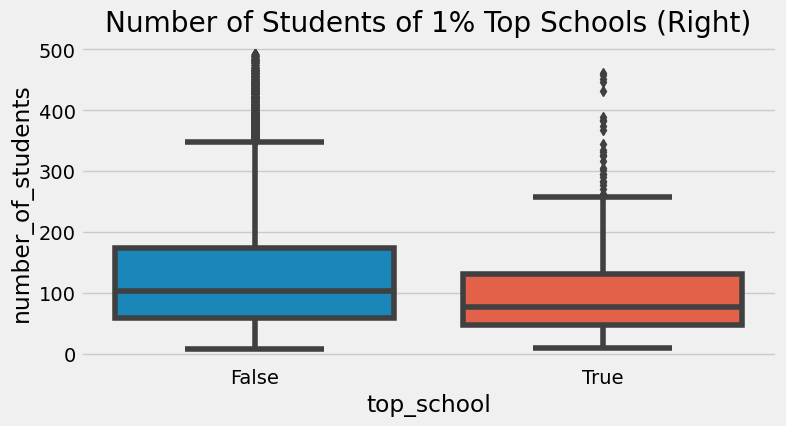

In [8]:
plot_data = (df.assign(top_school = df["avg_score"] >= np.quantile(df["avg_score"], .99))
             [["top_school", "number_of_students"]]
             .query(f"number_of_students<{np.quantile(df['number_of_students'], .98)}")) # remove outliers

plt.figure(figsize=(8,4))
ax = sns.boxplot(x="top_school", y="number_of_students", data=plot_data)

plt.title("Number of Students of 1% Top Schools (Right)")
plt.show()

- **하위 1% 학교도 학생 수가 적음**

    $\rightarrow$ **학생 수가 매우 적은 학교 (표본 크기가 작음)에서는 단순히 우연 때문에 점수가 매우 높거나 낮을 수 있음**
    
    $\rightarrow$ **규모가 큰 학교에서는 우연히 작용할 가능성이 적음**
    
    $\rightarrow$ **데이터 형태 기록의 부정확성**
    
    $\rightarrow$ **얼마나 부정확한가?**

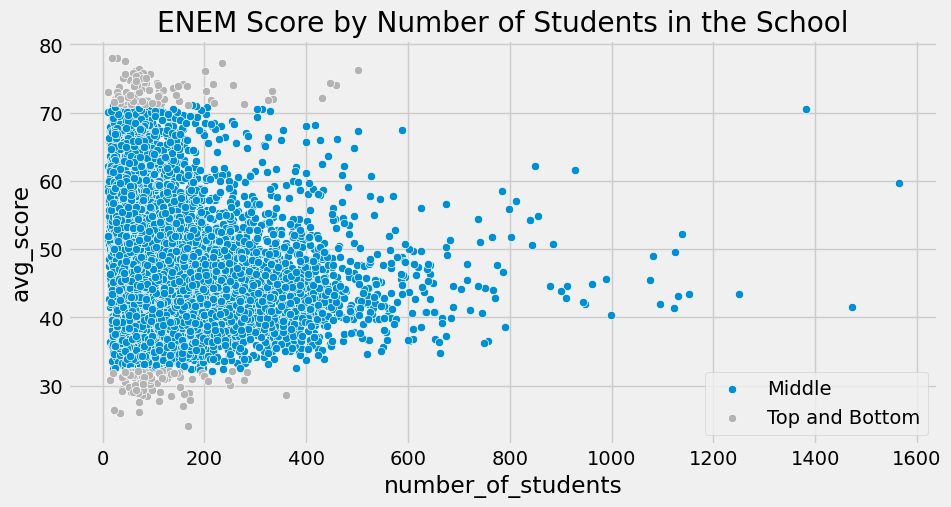

In [9]:
q_99 = np.quantile(df["avg_score"], .99)
q_01 = np.quantile(df["avg_score"], .01)

plot_data = (df
             .sample(10000)
             .assign(Group = lambda d: np.select([(d["avg_score"] > q_99) | (d["avg_score"] < q_01)],
                                                 ["Top and Bottom"], "Middle")))
plt.figure(figsize=(10,5))
sns.scatterplot(y="avg_score", x="number_of_students", data=plot_data.query("Group=='Middle'"), label="Middle")
ax = sns.scatterplot(y="avg_score", x="number_of_students", data=plot_data.query("Group!='Middle'"), color="0.7", label="Top and Bottom")

plt.title("ENEM Score by Number of Students in the School")
plt.show()

<br>

#### **추정값의 분산** : 불확실성의 정량화
- **분산은 관측값이 중심값(기댓값)에서 얼마나 벗어나는지의 척도**
- **불확실성은 관측한 데이터에서 양이 증가함에 따라 줄어듬**
    
    **이는 ATE를 포함한 모든 요약통계량에 해당**

<br>

#### 체계적 오차와 무작위 오차
- **체계적 오차 (Systematic Error)** : 측정값에 동일한 방식으로 영향을 미치는 일관된 편향
- **무작위 오차 (Random Error)** : 우연히 생긴 예측 불가능한 변동

<br>

- 체계적 오차 또는 편향은 데이터를 더 많이 수집한다고 해서 줄어들지 않으며,
    
    무작위 오차는 표본 크기가 증가함에 따라 줄어듬
    
    

<br>

<hr>

<br>

## 02.05 추정값의 표준오차
- 실험군과 대조군의 평균 차이 $E[Y|T=1] = E[Y|T=0]$로 $E[Y_1 - Y_0]$을 추정

<br>

- 이메일이 전환에 미치는 평균 처치효과

    - 짧은 이메일은 8% 이상의 효과, 긴 이메일은 1.3%의 작은 영향

        **이러한 효과가 우연히 따른 것이 아니라고 확신할 만큼 표본 크기가 충분하며, 통계적으로 유의한가?**
        
<br>

#### 표준오차 $SE$의 추정

In [10]:
data = pd.read_csv("./data/cross_sell_email.csv")
data.shape[0]

323

In [11]:
short_email = data.query("cross_sell_email=='short'")["conversion"]
long_email = data.query("cross_sell_email=='long'")["conversion"]
email = data.query("cross_sell_email!='no_email'")["conversion"]
no_email = data.query("cross_sell_email=='no_email'")["conversion"]

data.groupby("cross_sell_email").size()

cross_sell_email
long        109
no_email     94
short       120
dtype: int64

$$\hat{\sigma} = \sqrt{\frac{1}{{N-1}} \sum^N_{i=1}(x-\bar{x})^2}$$

In [12]:
def se(y: pd.Series):
    return y.std() / np.sqrt(len(y))

print("SE for Long Email:", se(long_email))
print("SE for Short Email:", se(short_email))

SE for Long Email: 0.02194602460918551
SE for Short Email: 0.030316953129541618


#### `.sem()` : `pandas`의 표준오차 계산

In [13]:
print("SE for Long Email:", long_email.sem())
print("SE for Short Email:", short_email.sem())

SE for Long Email: 0.02194602460918551
SE for Short Email: 0.030316953129541618


<br>

<hr>

<br>

## 02.06 신뢰구간
 
- 이메일 예시에서 실제 추상 분포가 $p=0.08$인 베르누이 분포를 따른다고 가정
    
    - $n=100$인 실험을 10,000번 진행


In [14]:
n = 100
conv_rate = 0.08

In [15]:
def run_experiment(): 
    return np.random.binomial(1, conv_rate, size=n)

In [16]:
np.random.seed(42)
experiments = [run_experiment().mean() for _ in range(10000)]

In [17]:
np.mean(experiments)

0.08020200000000001

- 100명을 대상으로 실험을 10,000번 진행했을 때의 전환율 (평균 전환) 분포

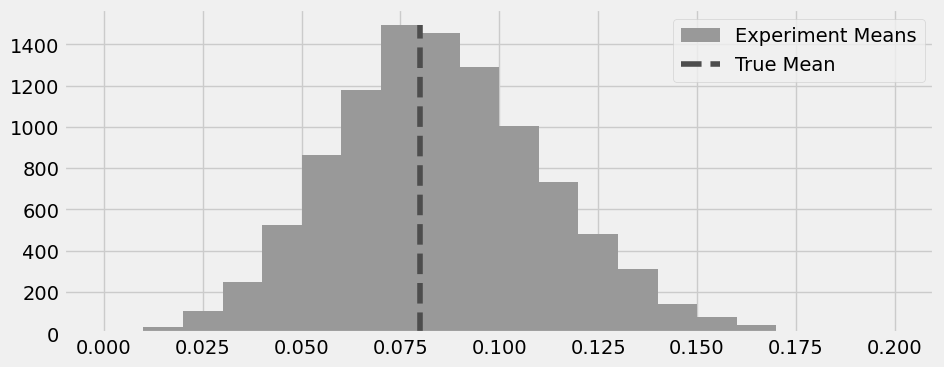

In [18]:
plt.figure(figsize=(10,4))
freq, bins, img = plt.hist(experiments, bins=20, label="Experiment Means", color="0.6")
plt.vlines(conv_rate, ymin=0, ymax=freq.max(), linestyles="dashed", label="True Mean", color="0.3")
plt.legend()
plt.show()

<br>

### 신뢰구간
- 모든 데이터 분석에 있어 10,000 번의 시뮬레이션 (실험)을 할 수 없음

    $\rightarrow$ **신뢰구간을 생성**
    
<br>

#### [중심극한 정리 (Central Limit Theorem)](https://ko.wikipedia.org/wiki/%EC%A4%91%EC%8B%AC_%EA%B7%B9%ED%95%9C_%EC%A0%95%EB%A6%AC)
- **표본평균의 크기는 표본의 개수 $N$이 무한에 수렴함에 따라, 정규분포에 수렴**

- **정규분포의 특성을 활용 : 정규분포 질량의 95%는 $\mu \pm 1.96\sigma$ 범위 내에 존재**

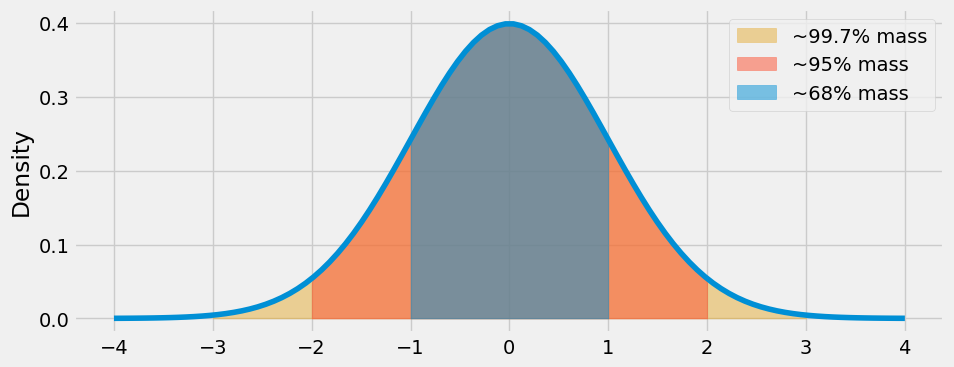

In [19]:
x = np.linspace(-4, 4, 100)
y = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(10,4))
plt.plot(x, y, linestyle="solid")
plt.fill_between(x.clip(-3, +3), 0, y, alpha=0.5, label="~99.7% mass", color="C2")
plt.fill_between(x.clip(-2, +2), 0, y, alpha=0.5, label="~95% mass", color="C1")
plt.fill_between(x.clip(-1, +1), 0, y, alpha=0.5, label="~68% mass", color="C0")
plt.ylabel("Density")
plt.legend()
plt.show()

<br>

#### 짧은 이메일 전환율의 95% 신뢰구간
- $[\mu - 1.96 \sigma, \mu + 1.96 \sigma]$

In [20]:
exp_se = short_email.sem()
exp_mu = short_email.mean()
ci = (exp_mu - 1.96 * exp_se, exp_mu + 1.96 * exp_se)
print("짧은 이메일 전환율의 95% CI: ", ci)

짧은 이메일 전환율의 95% CI:  (0.06557877186609842, 0.18442122813390158)


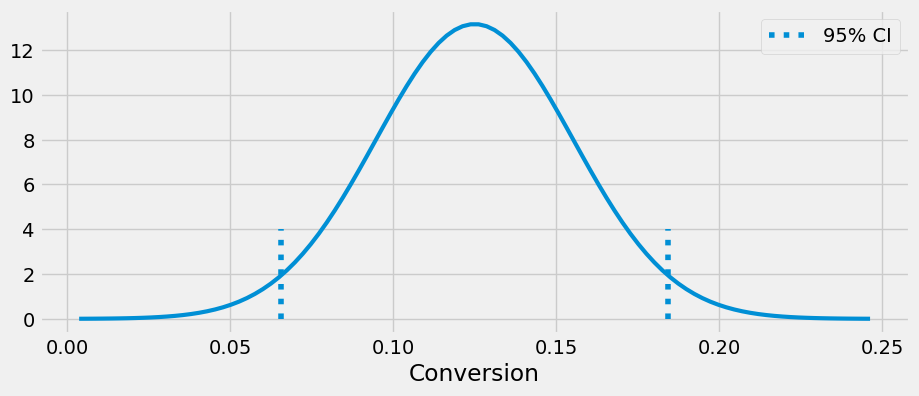

In [21]:
x = np.linspace(exp_mu - 4*exp_se, exp_mu + 4*exp_se, 100)
y = stats.norm.pdf(x, exp_mu, exp_se)

plt.figure(figsize=(10,4))
plt.plot(x, y, lw=3)
plt.vlines(ci[1], ymin=0, ymax=4, ls="dotted")
plt.vlines(ci[0], ymin=0, ymax=4, ls="dotted", label="95% CI")
plt.xlabel("Conversion")
plt.legend()
plt.show()

- 99% 신뢰구간
    - 표준편차에 정규분포의 질량중 99%를 포함하는 계수를 곱함
    
        $\rightarrow$ 표준화 정규분포의 누적분포함수값이 0.99가 되게 하는 값

In [22]:
from scipy import stats

In [23]:
z = np.abs(stats.norm.ppf((1-.99)/2))
print(z)
ci = (exp_mu - z * exp_se, exp_mu + z * exp_se)
ci

2.5758293035489004


(0.04690870373460816, 0.20309129626539185)

In [24]:
stats.norm.ppf((1-.99)/2)

-2.5758293035489004

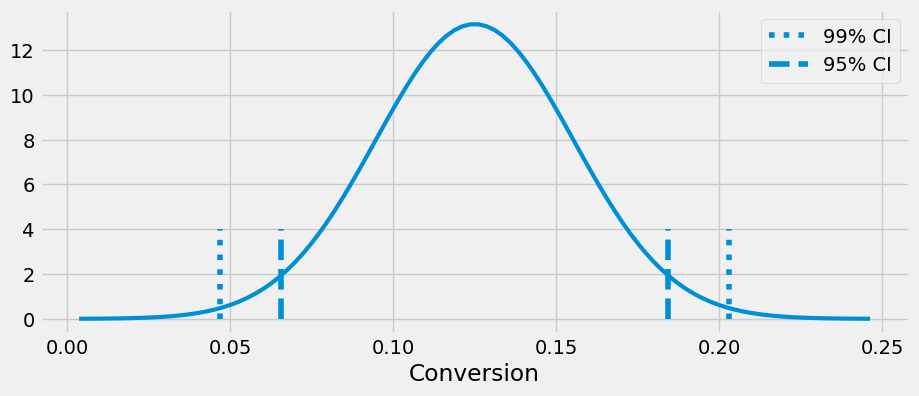

In [25]:
x = np.linspace(exp_mu - 4*exp_se, exp_mu + 4*exp_se, 100)
y = stats.norm.pdf(x, exp_mu, exp_se)

plt.figure(figsize=(10,4))
plt.plot(x, y, lw=3)
plt.vlines(ci[1], ymin=0, ymax=4, ls="dotted")
plt.vlines(ci[0], ymin=0, ymax=4, ls="dotted", label="99% CI")


ci_95 = (exp_mu - 1.96 * exp_se, exp_mu + 1.96 * exp_se)

plt.vlines(ci_95[1], ymin=0, ymax=4, ls="dashed")
plt.vlines(ci_95[0], ymin=0, ymax=4, ls="dashed", label="95% CI")
plt.xlabel("Conversion")
plt.legend()
plt.show()

<br>

#### 3개의 실험군의 신뢰구간

In [26]:
def ci(y: pd.Series):
    return (y.mean() - 2 * y.sem(), y.mean() + 2 * y.sem())

print("짧은 이메일 전환율의 95% CI:", ci(short_email))
print("긴 이메일 전환율의 95% CI:", ci(long_email))
print("이메일을 보내지 않았을 때의 전환율 95% CI:", ci(no_email))

짧은 이메일 전환율의 95% CI: (0.06436609374091676, 0.18563390625908324)
긴 이메일 전환율의 95% CI: (0.011153822341262012, 0.09893792077800405)
이메일을 보내지 않았을 때의 전환율 95% CI: (0.0006919679286838329, 0.08441441505003958)


- **신뢰구간이 겹친다고 해서 그룹 간의 차이가 통계적으로 유의하지 않다고 단정할 수 없음**
- **신뢰구간이 겹치지 않았다면 통계적으로 유의한 차이가 있음을 의미 $\rightarrow$ 겹치지 않는 신뢰구간은 통계적 유의성에 대한 보수적인 증거**
   

In [27]:
plt.figure(figsize=(10,4))

x = np.linspace(-0.05, .25, 100)
short_dist = stats.norm.pdf(x, short_email.mean(), short_email.sem())
plt.plot(x, short_dist, lw=2, label="Short", linestyle=linestyle[0])
plt.fill_between(x.clip(ci(short_email)[0], ci(short_email)[1]), 0, short_dist, alpha=0.2, color="0.0")

long_dist = stats.norm.pdf(x, long_email.mean(), long_email.sem())
plt.plot(x, long_dist, lw=2, label="Long", linestyle=linestyle[1])
plt.fill_between(x.clip(ci(long_email)[0], ci(long_email)[1]), 0, long_dist, alpha=0.2, color="0.4")

no_email_dist = stats.norm.pdf(x, no_email.mean(), no_email.sem())
plt.plot(x, no_email_dist, lw=2, label="No email", linestyle=linestyle[2])
plt.fill_between(x.clip(ci(no_email)[0], ci(no_email)[1]), 0, no_email_dist, alpha=0.2, color="0.8")

plt.xlabel("Conversion")
plt.legend()
plt.show()

NameError: name 'linestyle' is not defined

<Figure size 1000x400 with 0 Axes>

<br>

- **신뢰구간은 추정값에 대해 불확실성을 나타내는 방법**
- 표본크기가 작을수록 표준오차가 커지고, 그 결과 신뢰구간도 넓어짐

<br>

#### 신뢰구간의 해석
- **95% 신뢰구간이 95% 확률로 실제 평균을 포함하지 않음**
    
    **빈도주의 통계에서는 모집단 평균을 모집단 상수로 간주하기에, 실제 평균 (모집단 평균)을 포함할 수도, 포함하지 않을 수도 있음**
    

<br>

<hr>

<br>

## 02.07 가설검정
 
- 두 그룹 간의 평균 차이가 0(혹은 다른 특정값)과 통계적으로 유의한 차이가 있는지 검정

<br>

- **독립된 두 개의 정규분포의 합/차이 는 정규분포를 따름**
    
    - **평균은 두 분포 평균의 합/차이 이며, 분산은 두 분산의 합**
    
$$N(\mu_{1}, \sigma_{1}^2) - N(\mu_{2}, \sigma_{2}^2) = N(\mu_{1} - \mu_{2}, \sigma_{1}^2 + \sigma_{2}^2) \\ N(\mu_{1}, \sigma_{1}^2) + N(\mu_{2}, \sigma_{2}^2) = N(\mu_{1} + \mu_{2}, \sigma_{1}^2 + \sigma_{2}^2)$$

In [28]:
import seaborn as sns
from matplotlib import pyplot as plt

In [29]:
np.random.seed(123)

n1 = np.random.normal(4, 3, 30000)
n2 = np.random.normal(1, 4, 30000)
n_diff = n2 - n1

In [30]:
plt.figure(figsize=(10,4))
sns.distplot(n1, hist=False, label="$N(4,3^2)$", color="0.0", kde_kws={"linestyle":linestyle[0]})
sns.distplot(n2, hist=False, label="$N(1,4^2)$", color="0.4", kde_kws={"linestyle":linestyle[1]})
sns.distplot(n_diff, hist=False,
             label=f"$N(-3, 5^2) = N(1,4^2) - (4,3^2)$", color="0.8", kde_kws={"linestyle":linestyle[1]})
plt.legend();
plt.show()

NameError: name 'linestyle' is not defined

<Figure size 1000x400 with 0 Axes>

<br>

$$\mu_{diff} = \mu_{1} - \mu_{2}$$
$$SE_{diff} = \sqrt{SE_{1} + SE_{2}} = \sqrt{\frac{\sigma_{1}^2}{n_{1}} + \frac{\sigma_{2}^2}{n_{2}}}$$

<br>

### 귀무가설

$H_0\;:\;전환율_{\text{이메일을 보내지 않음}} = 전환율_{\text{짧은 이메일}}$

- 두 집단 (짧은 메일, 이메일을 보내지 않음)의 전환율 차이의 95% 신뢰구간은 0을 포함하지 않음
    
    $\rightarrow$ **95% 신뢰도 하 (유의수준 $\alpha=0.05$)에서 귀무가설 기각**
    

<br>

#### 유의수준
- **귀무가설이 참인데도 이를 기각하는 1종 오류의 확률**
* 데이터를 수집하거나 분석하기 전에 설정
    
    - 유의수준 $\alpha$를 목표로 한다면, $1-\alpha$ 신뢰구간을 구성해야 함

In [31]:
diff_mu = short_email.mean() - no_email.mean()
diff_se = np.sqrt(no_email.sem()**2 + short_email.sem()**2)

ci = (diff_mu - 1.96*diff_se, diff_mu + 1.96*diff_se)
print(f"두 집단 평균 차이 분포의 95% CI:\n{ci}")

두 집단 평균 차이 분포의 95% CI:
(0.010239808474398426, 0.15465380854687816)


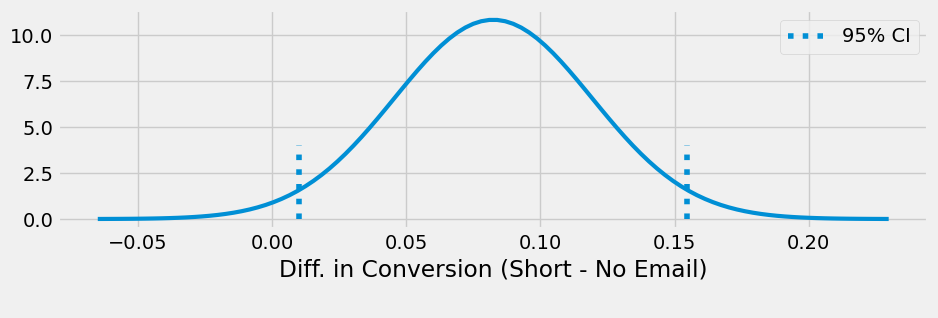

In [32]:
x = np.linspace(diff_mu - 4*diff_se, diff_mu + 4*diff_se, 100)
y = stats.norm.pdf(x, diff_mu, diff_se)

plt.figure(figsize=(10,3))
plt.plot(x, y, lw=3)
plt.vlines(ci[1], ymin=0, ymax=4, ls="dotted")
plt.vlines(ci[0], ymin=0, ymax=4, ls="dotted", label="95% CI")
plt.xlabel("Diff. in Conversion (Short - No Email)\n")
plt.legend()
plt.subplots_adjust(bottom=0.15)
plt.show()

<br>

#### 비열등성 시험 (Noninferioity Test)
- 대부분의 귀무가설을 두 그룹이 동등함 (차이가 0)을 전제로 하는 경우가 많지만, 이는 효과가 0과 유의하게 다른 경우에만 처치를 하려는 의도에서 비롯
- 어떤 상황에서는 처치효과가 0과 같을 때만 조치를 취하고 싶은 상황이 존재
    
    - 마케팅 캠페인을 중단하고자 할 떄, 마케팅 캠페인의 효과가 무시할 수 있을 정도로 작다면 (또는 비용을 상쇄할 정도로 충분히 높지 않다면) 캠페인을 지속할 이유가 없음
    
        이러한 상황에서는 매개변수가 특정값과 다른 경우를 귀무가설로 설정

<br>

- **또한 $H_0=0$의 귀무가설을 기각할 수 없다고 해서, 귀무가설이 진리는 아님**
    - $H_0 = 0$은 단순히 표본크기가 너무 작아서, 신뢰구간이 넓기 때문에 기각되지 않을 수도 있음
    
    $\rightarrow$ **비열등성 시험 : 신뢰구간에 0이 포함되는지 확인하는 동시에, 신뢰구간이 충분히 작은지 확인**

<br>

### 검정통계량
- **t-통계량** : 신뢰구간을 형성하는 분포를 정규화함으로써 정의

$$t_{diff} = \frac{\mu_{diff}-H_{0}}{SE_{diff}} = \frac{(\mu_{1}-\mu_{2}) - H_0}{\sqrt{\frac{\sigma_{1}^2}{n_{1}} + \frac{\sigma_{2}^2}{n_{2}}}}$$

- t-통계량의 분자는 관측한 평균 차이와 귀무가설 사이에 대한 차이 
    
    만약 귀무가설이 참이라면, 분자의 기댓값은 0
    
    
- 분모는 통계량의 분산이 1이 되도록 정규화하는 표준오차
        
    $\rightarrow$ **즉, 귀무가설 하에서 $t_{diff}$는 극단적인 값 이 나올 가능성이 매우 낮음**
    
    $\rightarrow$ **만약 극단적인 t-통계량이 나타난다면 귀무가설을 기각할 수 있다는 근거**

In [33]:
t_stat = (diff_mu - 0) / diff_se
print(t_stat)

2.237951231871536


<br>

#### t-분포와 정규분포
- t-검정에서는 표본 크기에서 추정하는 매개변수를 뺀 값인 자유도를 가진 t-분포를 사용
- 하지만, 표본 크기가 충분히 큰 경우 (100개 이상) 두 분포의 구분은 실질적으로 중요하지 않음


<br>

<hr>

<br>
 
## 02.08 p-값
- **귀무가설이 참이라고 가정할 때 관측된 결과보다 더 극단적인 결과가 실제로 관측될 확률**
    
    $\rightarrow$ **귀무가설이 참인 경우, 극단적인 데이터가 나타날 확률**
    
    $\rightarrow$ 귀무가설이 참일 때, 관측한 측정값이 얼마나 이례적인지 측정
    
<br>

$$P(data|H_0)$$

P-value: 0.025224235562152142


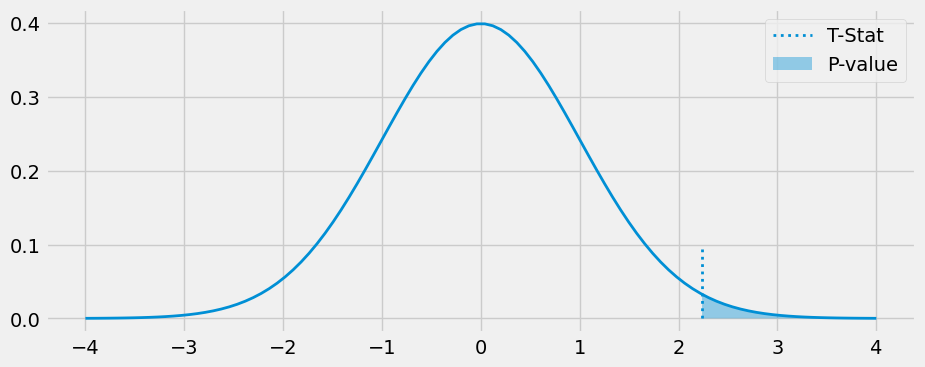

In [34]:
x = np.linspace(-4, 4, 100)
y = stats.norm.pdf(x, 0, 1)

print("P-value:", (1 - stats.norm.cdf(t_stat))*2)

plt.figure(figsize=(10,4))
plt.plot(x, y, lw=2)
plt.vlines(t_stat, ymin=0, ymax=0.1, ls="dotted", label="T-Stat", lw=2)
plt.fill_between(x.clip(t_stat), 0, y, alpha=0.4, label="P-value")
plt.legend()
plt.show()

<br>

<hr>

<br>

## 02.09 검정력 (Power of the test)

- 각 변수에 어떤 표본을 사용할지 결정해야 하는 경우,
    
    **교차 이메일 실험을 실행하지 않은 상태에서 몇 명의 고객에게 긴 이메일을 보낼지,**
    
    **몇 명에게 짧은 이메일을 보낼지,** 
    
    **몇 명에게 아예 이메일을 보내지 않을 지 결정?**
    
    $\rightarrow$ **이메일의 효과가 없다는 귀무가설이 거짓일 경우, 이를 정확히 기각할 만큼 충분히 큰 표본을 확보 해야 함**
    
    $\rightarrow$ **검정력 : 귀무가설을 올바르게 기각할 확률**
    
    - 검정력은 실험에 필요한 표본 크기를 파악할 때 뿐만 아니라, 제대로 실행하지 않은 실험에서 문제를 발견할 떄 유용
    
<br>

- **유의수준 $\alpha$ : 귀무가설을 잘못 기각할 확률**
- **검정력 $1-\beta$ : 귀무가설이 거짓인 경우, 이를 올바르게 기각할 확률**


<br>

| 귀무가설 | 채택 | 기각 |
| - | - | - |
| **참** | 1-$\alpha$ | **$\alpha$ (=1종 오류)**| 
| **거짓** | **$\beta$ (=2종 오류)** |1-$\beta$  | 

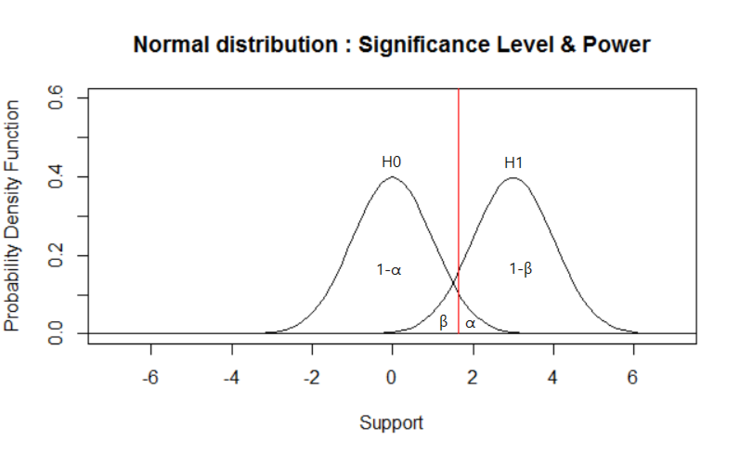

<br>

### 유의수준과 검정력의 관계
- $\alpha$를 낮게 설정하면, 제 2종 오류 확률 $\beta$는 증가
    
    $\rightarrow$ 검정력 $1-\beta$는 낮아짐
    
    $\rightarrow$ **기각역의 조정만으로 $\alpha$, $\beta$를 동시에 줄일 수 없음**

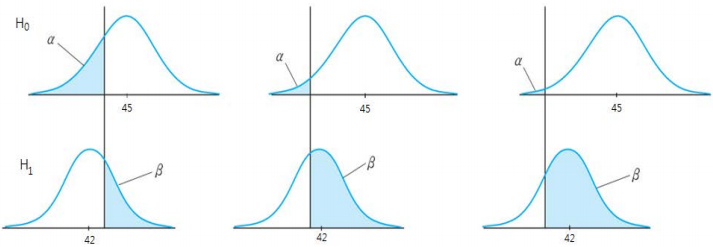

#### $\rightarrow$  적절한 표본크기의 설정을 통해 $\alpha$, $\beta$를 동시에 줄일 수 있음
- 표본크기 $n$이 큰 경우, $\alpha$, $\beta$가 작아짐을 확인할 수 있음
    
    $\rightarrow$ **가설검정에서 원하는 수준의 $\alpha$와 $\beta$에 해당하는 표본크기 결정 가능**

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdn%2Fbyz9Zq%2FbtqJrylSrqS%2Fb9KJT6Euboj2ajJtoxfxt1%2Fimg.png'>

- **효과크기 (Effect Size)** : 연구에서 관심 있는 차이 또는 관계의 크기
    - 대립가설이 주장하는 효과나 차이의 크기를 측정

### 표본 크기 계산 

<br>


### 단일 평균 검정

- 표본 크기 계산 공식:
$$n = \frac{(Z_{\alpha/2} + Z_{\beta})^2 \cdot \sigma^2}{d^2} $$


- $( Z_{\alpha/2} )$는 유의수준 $( \alpha )$에 대한 z-점수
- $( Z_{\beta} )$는 검정력(1 - β)에 대한 z-점수
- $( \sigma )$는 표준편차
- $( d )$는 효과 크기

<br>

### 두 평균 비교 (독립 샘플 t-검정)


$$n = \frac{(Z_{\alpha/2} + Z_{\beta})^2 \cdot (2 \cdot \sigma^2)}{d^2}$$

- 두 그룹의 표준편차가 동일하다고 가정

<br>

### 비율 비교

$$n = \frac{(Z_{\alpha/2} \cdot \sqrt{p_1 (1 - p_1) + p_2 (1 - p_2)} + Z_{\beta} \cdot \sqrt{p_1 (1 - p_1) + p_2 (1 - p_2)})^2}{(p_1 - p_2)^2}$$

- $p_1$과 $p_2$는 각각 두 그룹의 비율

<br>


### t-검정 예시

- 귀무가설 $(H_0)$: 두 그룹의 평균이 동일하다 $(\mu_A = \mu_B $).
- 대립가설 $(H_1)$: 두 그룹의 평균이 다르다 $(\mu_A \neq \mu_B $).

- **주어진 조건**:
  - 유의수준 $(\alpha$) = 0.05
  - 검정력 (1 - $\beta$) = 0.80
  - 기대하는 효과 크기 (Cohen's d) = 0.5
  - 표준편차 ($\sigma$) = 10 (두 그룹의 표준편차가 동일하다고 가정)


- **z-통계량**:
   - 유의수준 $\alpha = 0.05$에 대한 z-점수 (양측 검정): $ Z_{\alpha/2} \approx 1.96 $
   - 검정력 80%에 대한 z-점수: $ Z_{\beta} \approx 0.84 $


- **표본 크기 계산 공식**:
$$n = \frac{(Z_{\alpha/2} + Z_{\beta})^2 \cdot (2 \cdot \sigma^2)}{d^2}$$


- **계산**:
   - $Z_{\alpha/2} = 1.96$
   - $Z_{\beta} = 0.84$
   - $\sigma = 10$
   - $d = 0.5$

$$n = \frac{(1.96 + 0.84)^2 \cdot (2 \cdot 10^2)}{0.5^2}$$

$$n = 6272$$

- $n$은 하나의 그룹에 필요한 표본 크기

    $\rightarrow$ **필요한 표본 크기**: 약 6272 (각 그룹에 대해)

<hr>

<br>